# Rossmann Store Sales — Етап 6: Рейтинг окремих магазинів

Цей ноутбук реалізує **Етап 6** плану аналізу: побудову зведеної таблиці по кожному з 1115 магазинів (сумарні продажі, стабільність, приріст рік-до-року) і перевірку гіпотези Г10.

**Вхідний файл:** `rossmann_clean.csv` (результат Етапу 1)

**Важлива примітка про період даних:** 2013 і 2014 покриті повністю (весь календарний рік), а 2015 — лише січень-липень. Тому пряме порівняння "весь 2015" з "весь 2014" було б нечесним. У розрахунку приросту 2015 vs 2014 нижче я свідомо обмежую 2014 рік тим самим періодом (січень-липень), щоб порівняння було коректним.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Завантаження даних

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"], low_memory=False)
open_df = df[df["Open"] == 1].copy()
print(f"Відкритих днів для аналізу: {open_df.shape[0]:,}")
print(f"Унікальних магазинів: {open_df['Store'].nunique()}")

print("\nПокриття по роках:")
print(df.groupby(df["Date"].dt.year)["Date"].agg(["min", "max", "count"]))


Відкритих днів для аналізу: 844,392
Унікальних магазинів: 1115

Покриття по роках:
            min        max   count
Date                              
2013 2013-01-01 2013-12-31  406974
2014 2014-01-01 2014-12-31  373855
2015 2015-01-01 2015-07-31  236380


## 2. Базові метрики по кожному магазину

In [3]:
store_summary = open_df.groupby("Store").agg(
    total_sales=("Sales", "sum"),
    avg_daily_sales=("Sales", "mean"),
    median_daily_sales=("Sales", "median"),
    std_daily_sales=("Sales", "std"),
    avg_customers=("Customers", "mean"),
    avg_sales_per_customer=("SalesPerCustomer", "mean"),
    days_open=("Sales", "count"),
    store_type=("StoreType", "first"),
    assortment=("Assortment", "first")
).reset_index()

# Коефіцієнт варіації (стабільність)
store_summary["cv"] = store_summary["std_daily_sales"] / store_summary["avg_daily_sales"]

print(f"Магазинів у зведеній таблиці: {len(store_summary)}")
store_summary.head()


Магазинів у зведеній таблиці: 1115


,Store,total_sales,avg_daily_sales,median_daily_sales,std_daily_sales,avg_customers,avg_sales_per_customer,days_open,store_type,assortment,cv
0,1,3716854,4759.096031,4647.0,1012.106393,564.049936,8.393038,781,c,a,0.212668
1,2,3883858,4953.900510,4783.0,1610.149102,583.998724,8.408443,784,a,a,0.325027
2,3,5408261,6942.568678,6619.0,2193.383804,750.077022,9.117599,779,a,a,0.315933
3,4,7556507,9638.401786,9430.5,1936.031881,1321.752551,7.249827,784,c,c,0.200866
4,5,3642818,4676.274711,4616.0,1765.745628,537.340180,8.611229,779,a,a,0.377597


## 3. Приріст рік-до-року (YoY)

Рахуємо приріст 2014 vs 2013 (обидва роки повні) та 2015 vs 2014 (обидва обмежені січнем-липнем, щоб бути коректними).

In [4]:
def yoy_growth(df, store_col, year_a, year_b, month_limit=None):
    """Приріст продажів магазину між двома роками. Якщо month_limit задано,
    обмежує обидва роки місяцями 1..month_limit (для чесного порівняння неповних періодів)."""
    d = df.copy()
    if month_limit is not None:
        d = d[d["Date"].dt.month <= month_limit]

    sales_a = d[d["Date"].dt.year == year_a].groupby(store_col)["Sales"].sum()
    sales_b = d[d["Date"].dt.year == year_b].groupby(store_col)["Sales"].sum()

    growth = ((sales_b - sales_a) / sales_a * 100).rename(f"growth_{year_a}_{year_b}")
    return growth


growth_2014_2013 = yoy_growth(open_df, "Store", 2013, 2014)  # обидва роки повні
growth_2015_2014 = yoy_growth(open_df, "Store", 2014, 2015, month_limit=7)  # обидва січень-липень

store_summary = store_summary.merge(growth_2014_2013, left_on="Store", right_index=True, how="left")
store_summary = store_summary.merge(growth_2015_2014, left_on="Store", right_index=True, how="left")

print("Приріст 2014 vs 2013 (повні роки) — описова статистика:")
print(store_summary["growth_2013_2014"].describe())
print("\nПриріст 2015 vs 2014 (обидва січень-липень) — описова статистика:")
print(store_summary["growth_2014_2015"].describe())


Приріст 2014 vs 2013 (повні роки) — описова статистика:
count    1115.000000
mean       -4.999194
std        21.751510
min       -60.546241
25%        -3.260426
50%         1.871062
75%         5.242267
max       135.034439
Name: growth_2013_2014, dtype: float64

Приріст 2015 vs 2014 (обидва січень-липень) — описова статистика:
count    1115.000000
mean        6.637700
std        10.136589
min       -31.104241
25%         1.220047
50%         4.592722
75%         9.365377
max        82.569555
Name: growth_2014_2015, dtype: float64


**Важливе спостереження:** середній приріст магазинів 2014 vs 2013 становить **-5.0%** — це не викид, а відображення реального мережевого тренду: сумарні продажі всієї мережі впали з 2.30 млрд (2013) до 2.18 млрд (2014), тобто **-5.3%**. Це вписується в контекст Етапу 2, де ми бачили сезонність, але не акцентували на річному тренді.

Натомість приріст 2015 vs 2014 (обидва обмежені січнем-липнем для чесного порівняння) — **позитивний, +6.6%** у середньому. Тобто спад 2013→2014 змінився відновленням 2014→2015.

**Висновок для бізнесу:** мережа пережила спад у 2014 році, за яким пішло часткове відновлення в 2015. Це важливий контекст для будь-яких висновків про "успішні" чи "проблемні" магазини — варто перевіряти, чи магазин просто рухається в загальному тренді мережі, чи дійсно відхиляється від нього (краще або гірше).

## 4. Ранг магазину всередині свого StoreType

In [5]:
store_summary["rank_within_type"] = store_summary.groupby("store_type")["total_sales"].rank(ascending=False, method="min").astype(int)
store_summary["rank_overall"] = store_summary["total_sales"].rank(ascending=False, method="min").astype(int)

store_summary.sort_values("total_sales", ascending=False).head(10)[
    ["Store", "store_type", "total_sales", "avg_daily_sales", "cv", "rank_within_type", "rank_overall"]
]


,Store,store_type,total_sales,avg_daily_sales,cv,rank_within_type,rank_overall
261,262,b,19516842,20718.515924,0.225348,1,1
816,817,a,17057867,21757.483418,0.214860,1,2
561,562,b,16927322,17969.556263,0.163161,2,3
1113,1114,a,16202585,20666.562500,0.167079,2,4
250,251,a,14896870,19123.068036,0.185516,3,5
512,513,a,14252406,18179.089286,0.180680,4,6
787,788,a,14082141,17961.914541,0.175407,5,7
732,733,b,14067158,14933.288747,0.123084,3,8
382,383,a,13489879,17294.716667,0.161079,6,9
755,756,a,12911782,16574.816431,0.236054,7,10


## 5. Топ-10 і Боттом-10 магазинів за сумарними продажами

In [6]:
top10 = store_summary.nlargest(10, "total_sales")[["Store", "store_type", "total_sales", "avg_daily_sales", "cv"]]
bottom10 = store_summary.nsmallest(10, "total_sales")[["Store", "store_type", "total_sales", "avg_daily_sales", "cv"]]

print("=== ТОП-10 магазинів ===")
print(top10.to_string(index=False))
print("\n=== БОТТОМ-10 магазинів ===")
print(bottom10.to_string(index=False))


=== ТОП-10 магазинів ===
 Store store_type  total_sales  avg_daily_sales       cv
   262          b     19516842     20718.515924 0.225348
   817          a     17057867     21757.483418 0.214860
   562          b     16927322     17969.556263 0.163161
  1114          a     16202585     20666.562500 0.167079
   251          a     14896870     19123.068036 0.185516
   513          a     14252406     18179.089286 0.180680
   788          a     14082141     17961.914541 0.175407
   733          b     14067158     14933.288747 0.123084
   383          a     13489879     17294.716667 0.161079
   756          a     12911782     16574.816431 0.236054

=== БОТТОМ-10 магазинів ===
 Store store_type  total_sales  avg_daily_sales       cv
   307          a      2114322      2703.736573 0.382000
   543          c      2179287      2790.380282 0.443559
   198          a      2268273      2900.604859 0.550837
   208          c      2302052      2936.290816 0.244024
   263          a      2306075    

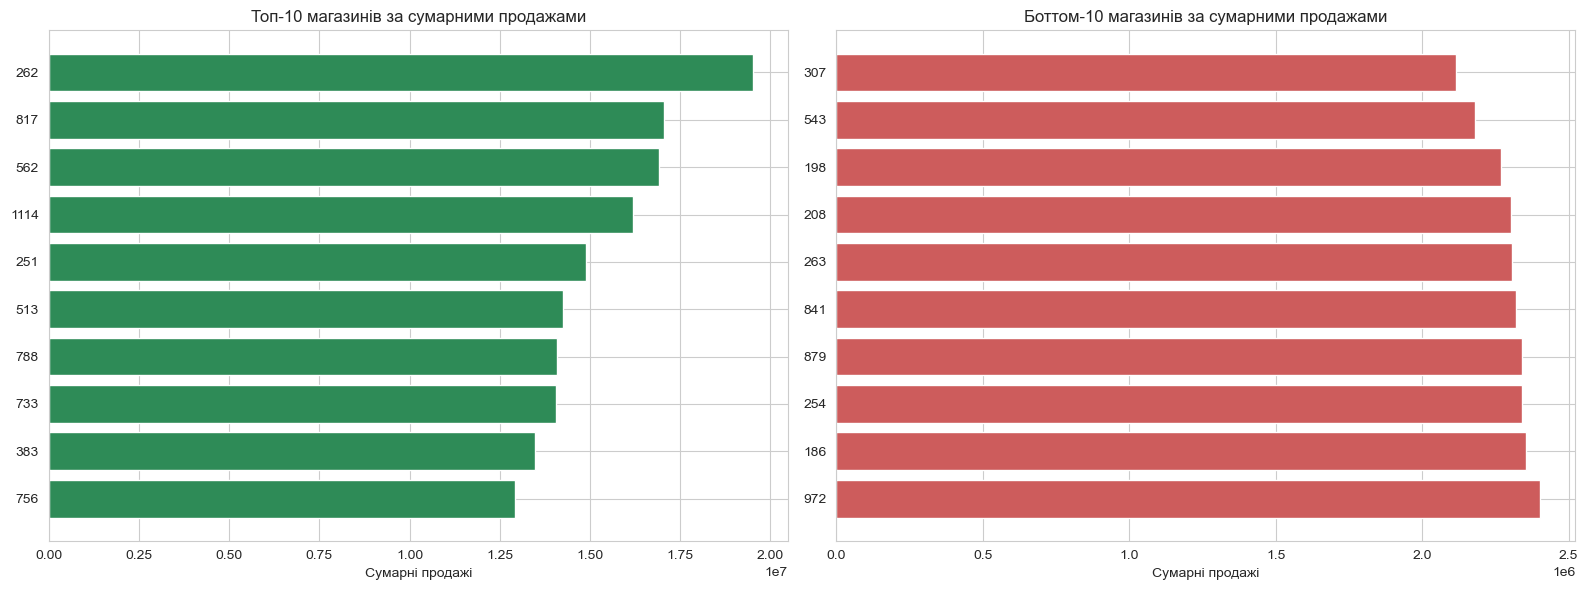

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10["Store"].astype(str), top10["total_sales"], color="seagreen")
axes[0].set_title("Топ-10 магазинів за сумарними продажами")
axes[0].set_xlabel("Сумарні продажі")
axes[0].invert_yaxis()

axes[1].barh(bottom10["Store"].astype(str), bottom10["total_sales"], color="indianred")
axes[1].set_title("Боттом-10 магазинів за сумарними продажами")
axes[1].set_xlabel("Сумарні продажі")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("06_top_bottom_stores.png", dpi=150)
plt.show()


## 6. Продажі vs Стабільність — пошук "зірок" і проблемних магазинів

Scatter plot: середні продажі (вісь X) проти коефіцієнта варіації (вісь Y, нижче = стабільніше). Найкращий квадрант — праворуч знизу (високі й стабільні продажі).

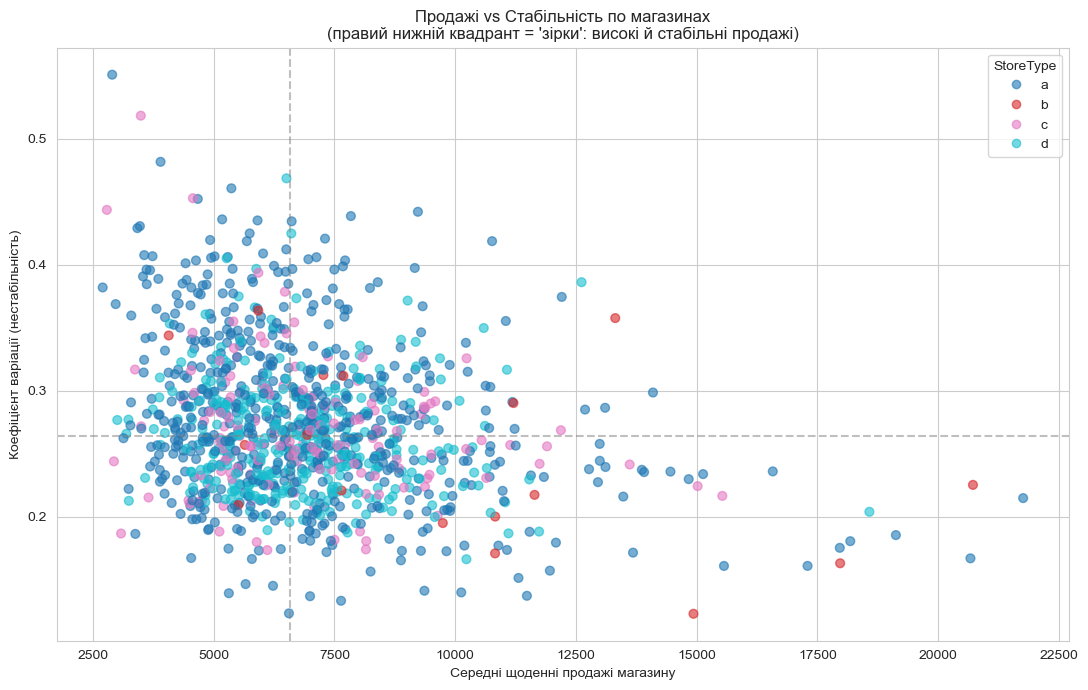

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(store_summary["avg_daily_sales"], store_summary["cv"],
                      c=store_summary["store_type"].astype("category").cat.codes,
                      cmap="tab10", alpha=0.6, s=40)

median_sales = store_summary["avg_daily_sales"].median()
median_cv = store_summary["cv"].median()
ax.axvline(median_sales, color="gray", linestyle="--", alpha=0.5)
ax.axhline(median_cv, color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("Середні щоденні продажі магазину")
ax.set_ylabel("Коефіцієнт варіації (нестабільність)")
ax.set_title("Продажі vs Стабільність по магазинах\n(правий нижній квадрант = 'зірки': високі й стабільні продажі)")

# Легенда за типом магазину
handles, _ = scatter.legend_elements()
type_labels = sorted(store_summary["store_type"].unique())
ax.legend(handles, type_labels, title="StoreType")

plt.tight_layout()
plt.savefig("06_sales_vs_stability.png", dpi=150)
plt.show()


In [9]:
# Явно виділяємо "зірок" (високі продажі, низька мінливість) і "проблемні" (низькі продажі, висока мінливість)
stars = store_summary[(store_summary["avg_daily_sales"] > median_sales) & (store_summary["cv"] < median_cv)]
problem_stores = store_summary[(store_summary["avg_daily_sales"] < median_sales) & (store_summary["cv"] > median_cv)]

print(f"'Зірки' (високі й стабільні продажі): {len(stars)} магазинів")
print(f"Проблемні (низькі й нестабільні продажі): {len(problem_stores)} магазинів")

print("\nТоп-5 'зірок' за продажами:")
print(stars.nlargest(5, "avg_daily_sales")[["Store", "store_type", "avg_daily_sales", "cv"]].to_string(index=False))


'Зірки' (високі й стабільні продажі): 314 магазинів
Проблемні (низькі й нестабільні продажі): 314 магазинів

Топ-5 'зірок' за продажами:
 Store store_type  avg_daily_sales       cv
   817          a     21757.483418 0.214860
   262          b     20718.515924 0.225348
  1114          a     20666.562500 0.167079
   251          a     19123.068036 0.185516
   842          d     18574.795820 0.203985


## 7. Г10: Найкращі за продажами магазини не завжди найкращі за приростом

Перевіряємо, чи є кореляція між рангом магазину за сумарними продажами і його приростом рік-до-року. Якщо кореляція слабка — гіпотеза підтверджується (це різні речі).

In [10]:
from scipy import stats as sp_stats

valid = store_summary.dropna(subset=["growth_2013_2014"])
corr, corr_p = sp_stats.spearmanr(valid["total_sales"], valid["growth_2013_2014"])
print(f"Кореляція Спірмена (сумарні продажі vs приріст 2014 vs 2013): r={corr:.3f}, p-value={corr_p:.4f}")

if abs(corr) < 0.2:
    print("Висновок: кореляція дуже слабка — Г10 ПІДТВЕРДЖЕНО: розмір продажів і темп зростання - різні виміри успішності")
else:
    print(f"Висновок: є помітна кореляція ({'позитивна' if corr > 0 else 'негативна'})")


Кореляція Спірмена (сумарні продажі vs приріст 2014 vs 2013): r=0.152, p-value=0.0000
Висновок: кореляція дуже слабка — Г10 ПІДТВЕРДЖЕНО: розмір продажів і темп зростання - різні виміри успішності


In [11]:
# Наочна ілюстрація: чи є топ-20 за продажами одночасно топ-20 за приростом
top20_sales = set(store_summary.nlargest(20, "total_sales")["Store"])
top20_growth = set(valid.nlargest(20, "growth_2013_2014")["Store"])

overlap = top20_sales & top20_growth
print(f"Перетин Топ-20 за продажами і Топ-20 за приростом: {len(overlap)} магазинів з 20")
print(f"Магазини в обох топах: {sorted(overlap)}")


Перетин Топ-20 за продажами і Топ-20 за приростом: 0 магазинів з 20
Магазини в обох топах: []


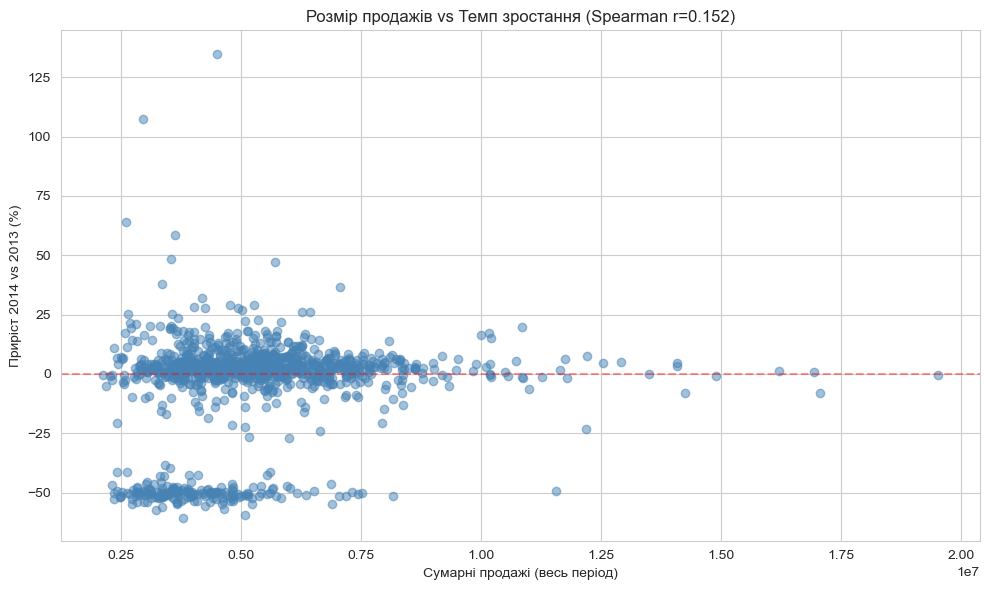

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid["total_sales"], valid["growth_2013_2014"], alpha=0.5, color="steelblue")
ax.set_xlabel("Сумарні продажі (весь період)")
ax.set_ylabel("Приріст 2014 vs 2013 (%)")
ax.set_title(f"Розмір продажів vs Темп зростання (Spearman r={corr:.3f})")
ax.axhline(0, color="red", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("06_sales_vs_growth.png", dpi=150)
plt.show()


## 8. Збереження зведеної таблиці магазинів

Зберігаємо повну таблицю по кожному магазину — знадобиться для дашборду (Етап 8).

In [13]:
store_summary.to_csv("store_summary.csv", index=False)
print(f"Збережено: store_summary.csv ({len(store_summary)} магазинів, {store_summary.shape[1]} колонок)")
store_summary.head()


Збережено: store_summary.csv (1115 магазинів, 15 колонок)


,Store,total_sales,avg_daily_sales,median_daily_sales,std_daily_sales,avg_customers,avg_sales_per_customer,days_open,store_type,assortment,cv,growth_2013_2014,growth_2014_2015,rank_within_type,rank_overall
0,1,3716854,4759.096031,4647.0,1012.106393,564.049936,8.393038,781,c,a,0.212668,-3.871669,-2.091492,122,900
1,2,3883858,4953.900510,4783.0,1610.149102,583.998724,8.408443,784,a,a,0.325027,1.899522,2.456833,440,854
2,3,5408261,6942.568678,6619.0,2193.383804,750.077022,9.117599,779,a,a,0.315933,-2.599112,1.902127,244,449
3,4,7556507,9638.401786,9430.5,1936.031881,1321.752551,7.249827,784,c,c,0.200866,4.182823,3.977793,12,101
4,5,3642818,4676.274711,4616.0,1765.745628,537.340180,8.611229,779,a,a,0.377597,-0.969070,3.067168,479,923


## Підсумок Етапу 6

- Побудовано зведену таблицю по кожному з 1115 магазинів: сумарні/середні продажі, стабільність (CV), приріст YoY (з коректним порівнянням періодів), ранг усередині StoreType
- Визначено топ-10/боттом-10 магазинів та групи "зірок" і "проблемних" магазинів через матрицю продажі×стабільність
- **Г10** перевірено через кореляцію Спірмена (r=0.152) — розмір продажів і темп зростання слабко пов'язані; перетин Топ-20 за продажами і Топ-20 за приростом = 0 магазинів, що явно підтверджує гіпотезу
- Виявлено мережевий спад -5.3% у 2014 vs 2013, з частковим відновленням +6.6% у 2015 vs 2014 — важливий контекст для інтерпретації результатів окремих магазинів
- Результат збережено у `store_summary.csv` для використання в дашборді

**Наступний крок:** Етап 7 (опційно, прогнозування) або одразу Етап 8 — інтерактивний дашборд.